In [2]:
# Copyright 2024 Bytedance Ltd. and/or its affiliates
# Copyright 2022 EleutherAI and the HuggingFace Inc. team. All rights reserved.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# Adapted from https://github.com/EleutherAI/lm-evaluation-harness/blob/main/lm_eval/tasks/hendrycks_math/utils.py


def compute_score(solution_str, ground_truth) -> float:
    retval = 0.0
    try:
        string_in_last_boxed = last_boxed_only_string(solution_str)
        if string_in_last_boxed is not None:
            answer = remove_boxed(string_in_last_boxed)
            if is_equiv(answer, ground_truth):
                retval = 1.0
    except Exception as e:
        print(e)

    return retval


# string normalization from https://github.com/EleutherAI/lm-evaluation-harness/blob/master/lm_eval/tasks/hendrycks_math.py
def is_equiv(str1, str2, verbose=False):
    if str1 is None and str2 is None:
        print("WARNING: Both None")
        return True
    if str1 is None or str2 is None:
        return False

    try:
        ss1 = strip_string(str1)
        ss2 = strip_string(str2)
        if verbose:
            print(ss1, ss2)
        return ss1 == ss2
    except Exception:
        return str1 == str2


def remove_boxed(s):
    if "\\boxed " in s:
        left = "\\boxed "
        assert s[: len(left)] == left
        return s[len(left) :]

    left = "\\boxed{"

    assert s[: len(left)] == left
    assert s[-1] == "}"

    return s[len(left) : -1]


def last_boxed_only_string(string):
    idx = string.rfind("\\boxed")
    if "\\boxed " in string:
        return "\\boxed " + string.split("\\boxed ")[-1].split("$")[0]
    if idx < 0:
        idx = string.rfind("\\fbox")
        if idx < 0:
            return None

    i = idx
    right_brace_idx = None
    num_left_braces_open = 0
    while i < len(string):
        if string[i] == "{":
            num_left_braces_open += 1
        if string[i] == "}":
            num_left_braces_open -= 1
            if num_left_braces_open == 0:
                right_brace_idx = i
                break
        i += 1

    retval = None if right_brace_idx is None else string[idx : right_brace_idx + 1]

    return retval


def fix_fracs(string):
    substrs = string.split("\\frac")
    new_str = substrs[0]
    if len(substrs) > 1:
        substrs = substrs[1:]
        for substr in substrs:
            new_str += "\\frac"
            if substr[0] == "{":
                new_str += substr
            else:
                try:
                    assert len(substr) >= 2
                except:  # noqa: E722
                    return string
                a = substr[0]
                b = substr[1]
                if b != "{":
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}{" + b + "}" + post_substr
                    else:
                        new_str += "{" + a + "}{" + b + "}"
                else:
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}" + b + post_substr
                    else:
                        new_str += "{" + a + "}" + b
    string = new_str
    return string


def fix_a_slash_b(string):
    if len(string.split("/")) != 2:
        return string
    a = string.split("/")[0]
    b = string.split("/")[1]
    try:
        a = int(a)
        b = int(b)
        assert string == "{}/{}".format(a, b)
        new_string = "\\frac{" + str(a) + "}{" + str(b) + "}"
        return new_string
    except:  # noqa: E722
        return string


def remove_right_units(string):
    # "\\text{ " only ever occurs (at least in the val set) when describing units
    if "\\text{" in string:
        splits = string.split("\\text{")
        assert len(splits) == 2
        return splits[1][:-1]
    else:
        return string


def fix_sqrt(string):
    if "\\sqrt" not in string:
        return string
    splits = string.split("\\sqrt")
    new_string = splits[0]
    for split in splits[1:]:
        if split[0] != "{":
            a = split[0]
            new_substr = "\\sqrt{" + a + "}" + split[1:]
        else:
            new_substr = "\\sqrt" + split
        new_string += new_substr
    return new_string


def strip_string(string):
    # linebreaks
    string = string.replace("\n", "")

    # remove inverse spaces
    string = string.replace("\\!", "")

    # replace \\ with \
    string = string.replace("\\\\", "\\")

    # replace tfrac and dfrac with frac
    string = string.replace("tfrac", "frac")
    string = string.replace("dfrac", "frac")

    # remove \left and \right
    string = string.replace("\\left", "")
    string = string.replace("\\right", "")

    # Remove circ (degrees)
    string = string.replace("^{\\circ}", "")
    string = string.replace("^\\circ", "")

    # remove dollar signs
    string = string.replace("\\$", "")

    # remove units (on the right)
    string = remove_right_units(string)

    # remove percentage
    string = string.replace("\\%", "")
    string = string.replace("\%", "")  # noqa: W605

    # " 0." equivalent to " ." and "{0." equivalent to "{." Alternatively, add "0" if "." is the start of the string
    string = string.replace(" .", " 0.")
    string = string.replace("{.", "{0.")
    # if empty, return empty string
    if len(string) == 0:
        return string
    if string[0] == ".":
        string = "0" + string

    # to consider: get rid of e.g. "k = " or "q = " at beginning
    if len(string.split("=")) == 2 and len(string.split("=")[0]) <= 2:
        string = string.split("=")[1]

    # fix sqrt3 --> sqrt{3}
    string = fix_sqrt(string)

    # remove spaces
    string = string.replace(" ", "")

    # \frac1b or \frac12 --> \frac{1}{b} and \frac{1}{2}, etc. Even works with \frac1{72} (but not \frac{72}1).
    # Also does a/b --> \\frac{a}{b}
    string = fix_fracs(string)

    # manually change 0.5 --> \frac{1}{2}
    if string == "0.5":
        string = "\\frac{1}{2}"

    # NOTE: X/Y changed to \frac{X}{Y} in dataset, but in simple cases fix in case the model output is X/Y
    string = fix_a_slash_b(string)

    return string


<>:192: SyntaxWarning: invalid escape sequence '\%'
<>:192: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_635725/2186628116.py:192: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "")  # noqa: W605


In [31]:
import pandas as pd
import json
from transformers import AutoTokenizer
from tqdm.auto import tqdm
tqdm.pandas()

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", trust_remote_code=True)

import pandas as pd
import json
import re

# 1. 定义答案提取函数
def extract_answer(text):
    if not isinstance(text, str):
        return ""
    # 匹配 \boxed{内容},取最后一个匹配项（通常是最终结论）
    patterns = [
        r'\\boxed\{([^{}]*(?:\{[^{}]*\}[^{}]*)*)\}', # 处理嵌套大括号
        r'The answer is[:\s]*([^\.]+)',             # 备选：非 LaTeX 格式
    ]
    for pattern in patterns:
        matches = re.findall(pattern, text)
        if matches:
            return matches[-1].strip()
    return ""

def is_correct_v3(model_output, ground_truth):
    """
    model_output: 模型生成的完整文本 (包含思考过程)
    ground_truth: 数据集里的标准答案 (通常是已经提取出来的答案字符串)
    """
    try:
        # 1. 找到模型输出中最后一个 \boxed{} 的内容
        extracted_box = last_boxed_only_string(model_output)
        
        if extracted_box is None:
            # 如果没找到 boxed，这道题通常判定为错
            return False
            
        # 2. 去掉 \boxed{} 外壳
        # 注意：这里加个 try 因为 remove_boxed 里面有 assert，失败会报错
        try:
            model_answer = remove_boxed(extracted_box)
        except:
            # 处理类似 \boxed 后面没带括号的极端情况
            model_answer = extracted_box.replace("\\boxed", "").strip("{} ")

        # 3. 使用官方的等价性判断函数
        # is_equiv 内部会调用那套复杂的 strip_string 逻辑
        return is_equiv(model_answer, ground_truth)
        
    except Exception as e:
        # 打印错误方便调试，实际跑大规模数据时可以关掉
        # print(f"Eval Error: {e}")
        return False
    
# 3. 读取数据
file_path = "/workspace/yiqiuguo/lsrl/qwen3-1.7b_math-500_rollout8_len32768_final.jsonl"
results = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        results.append(json.loads(line))

# 4. 核心评估逻辑
eval_data = []
for item in results:
    gold_answer = item.get('answer', '')
    responses = item.get('responses', [])
    
    # 提取这 8 个回复的预测值
    preds = [res for res in responses]
    # 判断每一个是否正确 (True/False 列表)
    correctness = [is_correct_v3(p, gold_answer) for p in preds]
    
    eval_data.append({
        "problem": item.get('problem', '')[:50] + "...",
        "gold": gold_answer,
        "preds": preds,
        "correctness": correctness,
        "num_correct": sum(correctness),
        "any_correct": any(correctness) # Pass@8 的基础
    })

eval_df = pd.DataFrame(eval_data)

# 5. 计算指标
total_questions = len(eval_df)
# Pass@1: 所有生成的回复中正确的比例 (Total_Correct / (Total_Questions * 8))
pass_at_1 = eval_df['num_correct'].sum() / (total_questions * 8)
# Pass@8: 至少有一个回复正确的题目比例
pass_at_8 = eval_df['any_correct'].mean()

# --- 打印结果 ---
print("-" * 30)
print(f"📊 评测报告 (基于 {total_questions} 道题)")
print("-" * 30)
print(f"✅ Pass @ 1 (平均准确率): {pass_at_1:.2%}")
print(f"🚀 Pass @ 8 (至少对一个): {pass_at_8:.2%}")
print("-" * 30)

# 展示部分细节：哪些是对的，哪些是错的
display_cols = ['gold', 'num_correct', 'any_correct', 'correctness']
print("\n前 5 条数据详情 (correctness 列表展示了 8 个回复的对错):")
eval_df[display_cols].head()

# 1. 筛选 8 次尝试全部错误的数据
# conditions: any_correct 为 False
wrong_df = eval_df[eval_df['any_correct'] == False].copy()

# 2. 将这些错误数据收集到一个 list 中
# 包含：原始问题、标准答案、以及模型那 8 个全错的回复（方便分析错在哪）
wrong_data = []

for idx, row in wrong_df.iterrows():
    # 重新从原始结果中获取完整的 responses（之前 eval_df 为了展示只存了前50个字符）
    # 假设你的原始数据在 results 列表里，索引是一致的
    original_item = results[idx] 
    
    wrong_data.append({
        "problem": original_item.get('problem'),
        "gold_answer": original_item.get('answer'),
        "bad_responses": original_item.get('responses'), # 这 8 个都是错的
        "extracted_preds": row['preds']                  # 对应提取出的错误答案
    })

# 3. 打印统计信息
print(f"统计结果：")
print(f"总题目数: {len(results)}")
print(f"全错题目数 (Wrong Data): {len(wrong_data)}")
print(f"模型全错率: {len(wrong_data) / len(results):.2%}")

# 4. 展示一个典型“翻车”案例
if wrong_data:
    print("\n--- 典型错误案例展示 ---")
    example = wrong_data[0]
    print(f"【题目】: {example['problem']}")
    print(f"【标准答案】: {example['gold_answer']}")
    # print(f"【模型第一个错误尝试提取值】: {example['extracted_preds'][0]}")
    
    # print('【bad_responses】: ', example['bad_responses'][0])
    extracted_box = last_boxed_only_string(example['bad_responses'][0])
    model_answer = remove_boxed(extracted_box)
    print('【model_answer】: ', model_answer)
    sp = example['gold_answer'].split("\\text{")
    print(f"【remove_right_units split gold】: {sp}")
    print(f"【remove_right_units gold】: {remove_right_units(example['gold_answer'])}")
    print(f"【strip gold】: {strip_string(example['gold_answer'])}")
    print('【is_equivalent】: ', is_equiv(model_answer, example['gold_answer']))
    
new_wrong_data = []

# 遍历之前判断为“全错”的数据
# 假设 wrong_data_final 是通过 is_correct_v3 判定为 any_correct == False 的原始数据列表
for item in wrong_data:
    problem = item.get('problem')
    gold = item.get('gold_answer')
    responses = item.get('bad_responses', [])
    
    # 筛选出那些真正输出了 \boxed 的回复
    complete_but_wrong_responses = []
    
    # print('gold: ', gold)
    for res in responses:
        # 使用你提供的官方函数检测是否有完整的 boxed
        boxed_str = last_boxed_only_string(res)
        
        if boxed_str is not None and remove_boxed(boxed_str) not in gold.strip():
            # print('boxed_str: ', boxed_str)
            # 既然在 wrong_data_final 里，说明这个 res 肯定是不对的
            # 我们只需要确认它“写完了”
            complete_but_wrong_responses.append(res)
    
    # 如果这个题目中，至少有一个回复是“完整写完但写错”的，我们就记录下来
    if len(complete_but_wrong_responses) > 0:
        new_entry = item.copy()
        # 更新 responses 列表，只保留那些完整输出的错误回复
        new_entry['complete_wrong_responses'] = complete_but_wrong_responses
        new_wrong_data.append(new_entry)

# --- 打印分析结果 ---
print(f"📊 过滤结果:")
print(f"原本全错的题目数: {len(wrong_data)}")
print(f"其中包含完整输出的‘硬核’错误题目数 (new_wrong_data): {len(new_wrong_data)}")

# 展示一个
if new_wrong_data:
    example = new_wrong_data[0]
    print("\n--- 完整输出但错误的案例 ---")
    print(f"题目: {example['problem']}")
    print(f"标准答案: {example['gold_answer']}")
    print(f"模型给出的错误结论: {remove_boxed(last_boxed_only_string(example['complete_wrong_responses'][0]))}")
    
# all_len = pd.DataFrame(new_wrong_data).apply(lambda row: list(tok(row['complete_wrong_responses'], return_length=True)['length']), axis=1).sum()
# print(min(all_len), max(all_len), sum(all_len) / len(all_len),len(all_len))
# pd.DataFrame(all_len).hist(bins=100)

import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from torch.optim import Adam

# 1. 加载模型与分词器 (transformers 格式)
model_name = "Qwen/Qwen3-1.7B"
tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

def apply_chat_template(tok, prompt):
    # 构造对话结构
    messages = [
        {"role": "user", "content": prompt}
    ]
    
    # 应用 Chat Template
    # tokenize=False 返回字符串，add_generation_prompt=True 添加助手引导符
    prompt_text = tok.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    # 3. 核心修改：在助手回复的开头强制注入 <think> 标记
    # 这样模型会从 <think> 之后开始补全，从而触发推理逻辑
    prompt_text += "<think>"
    return prompt_text

# 2. 准备 Wrong Data 中的一条数据 (示例)
# 假设你的 wrong_data 结构中已经有了成功的 think 路径但答案错了，或者你想优化这段 think
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for i,sample in enumerate(new_wrong_data):
    # sample = new_wrong_data[18] 
    question_text = apply_chat_template(tok, sample['problem']) # 包含 <think> 的完整 prompt
    answer_text = sample['complete_wrong_responses'][0] # 包含 <think> 的完整 prompt
    thinking_text = answer_text.split("</think>")[0] # 提取 <think> 中的内容
    after_thinking_text = answer_text.split("</think>")[1] # 提取 <think> 后的内容
    assert "\\boxed{" in after_thinking_text, "确保 <think> 后面有 boxed 结果"
    pred_box_text = last_boxed_only_string(after_thinking_text)
    connector_text = after_thinking_text.split(pred_box_text)[0] # 提取 <think> 后的内容
    gt_text = "\\boxed{" + sample['gold_answer'].strip() + "}"
    s = scorer.score(remove_boxed(pred_box_text), remove_boxed(gt_text))['rougeL'].fmeasure
    # if not(len(tok(answer_text)['input_ids']) < 8000 and s < 0.2):
    #     continue # 过滤掉过长的输入和已经正确的预测（因为我们想优化错误的预测）
    print('i: ', i)
    print('s: ', s)
    print('【question_text】: ', question_text)
    # print("【question token num】：", len(tok(question_text)['input_ids']))
    print("【answer token num】：", len(tok(answer_text)['input_ids']))
    # print('【answer_text】: ', answer_text)
    # print('【thinking_text】: ', thinking_text)
    # print('【after_thinking_text】: ', after_thinking_text) 
    # print('【connector_text】: ', connector_text)
    print('【pred_box_text】: ', pred_box_text)
    print('【gt_text】: ', gt_text)
    print('【pred_box_text】: ', remove_boxed(pred_box_text))
    print('【gt_text】: ', remove_boxed(gt_text))
    # break

# real_bad_sample_idxs=[0,3,4,8,10,11,13,14,17,21,22,23]
sample = new_wrong_data[17] 

question_text = apply_chat_template(tok, sample['problem']) # 包含 <think> 的完整 prompt
answer_text = sample['complete_wrong_responses'][0] # 包含 <think> 的完整 prompt
thinking_text = answer_text.split("</think>")[0] # 提取 <think> 中的内容
after_thinking_text = answer_text.split("</think>")[1] # 提取 <think> 后的内容
assert "\\boxed{" in after_thinking_text, "确保 <think> 后面有 boxed 结果"
pred_box_text = last_boxed_only_string(after_thinking_text)
# assert 0 < len(after_thinking_text.split(pred_box_text)) <= 2, "确保 <think> 后面只有一个 boxed 结果"
connector_text = after_thinking_text.split(pred_box_text)[0] + "\\boxed{" # 提取 <think> 后的内容并加上 \boxed{
gt_text = sample['gold_answer'].strip()
s = scorer.score(remove_boxed(pred_box_text), (gt_text))['rougeL'].fmeasure
print('【question_text】: ', question_text)
# print("【question token num】：", len(tok(question_text)['input_ids']))
print("【answer token num】：", len(tok(answer_text)['input_ids']))
# print('【answer_text】: ', answer_text)
# print('【thinking_text】: ', thinking_text)
# print('【after_thinking_text】: ', after_thinking_text) 
# print('【connector_text】: ', connector_text)
print('【pred_box_text】: ', pred_box_text)
print('【gt_text】: ', gt_text)
# print('【pred_box_text noboxed】: ', remove_boxed(pred_box_text))
# print('【gt_text noboxed】: ', remove_boxed(gt_text))
    

------------------------------
📊 评测报告 (基于 500 道题)
------------------------------
✅ Pass @ 1 (平均准确率): 87.62%
🚀 Pass @ 8 (至少对一个): 93.00%
------------------------------

前 5 条数据详情 (correctness 列表展示了 8 个回复的对错):
统计结果：
总题目数: 500
全错题目数 (Wrong Data): 35
模型全错率: 7.00%

--- 典型错误案例展示 ---
【题目】: The expression $2\cdot 3 \cdot 4\cdot 5+1$ is equal to 121, since multiplication is carried out before addition. However, we can obtain values other than 121 for this expression if we are allowed to change it by inserting parentheses. For example, we can obtain 144 by writing \[
(2\cdot (3\cdot 4)) \cdot (5+1) = 144.
\]In total, how many values can be obtained from the expression $2\cdot 3\cdot 4 \cdot 5 + 1$ by inserting parentheses? (Note that rearranging terms is not allowed, only inserting parentheses).
【标准答案】: 4
【model_answer】:  23
【remove_right_units split gold】: ['4']
【remove_right_units gold】: 4
【strip gold】: 4
【is_equivalent】:  False
📊 过滤结果:
原本全错的题目数: 35
其中包含完整输出的‘硬核’错误题目数 (new_wrong_data): 24

--- 

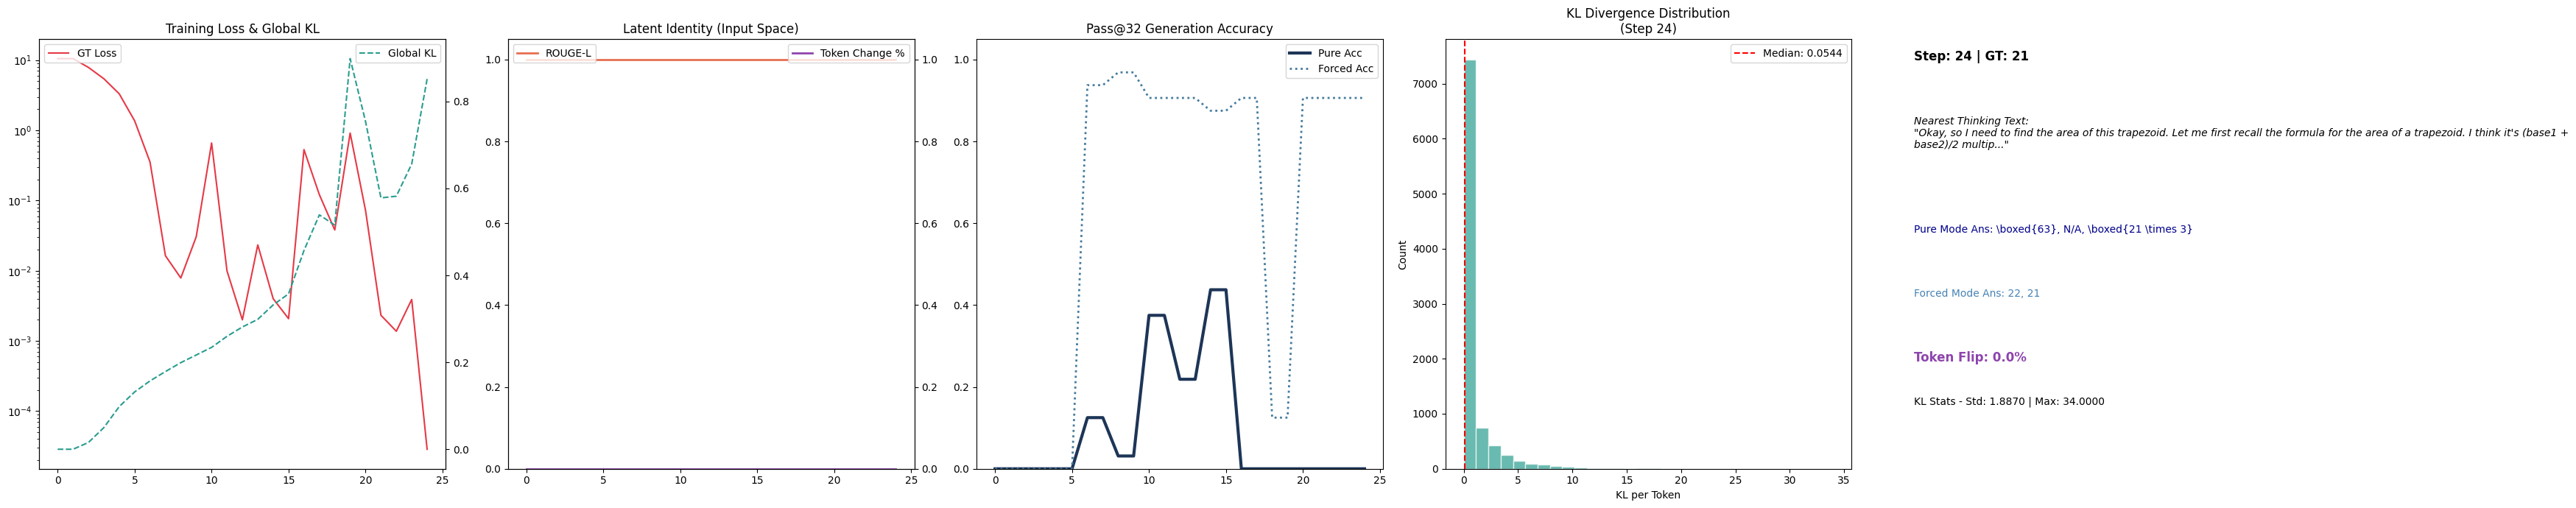

KeyboardInterrupt: 

In [27]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from IPython import display
from rouge_score import rouge_scorer
from torch.optim import Adam
import re
from transformers import AutoModelForCausalLM
import requests
import torch
import io
import base64
from transformers import AutoTokenizer

# 提前在全局初始化 Tokenizer，避免每次生成时重复加载
MODEL_NAME = model_name
# 必须加上 trust_remote_code=True
TOKENIZER = tok

model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map="auto", 
    torch_dtype=torch.bfloat16, # 建议用 bf16 匹配 Qwen 训练格式
    trust_remote_code=True
)

# 提取词表全集用于寻找最近邻 (Input Space Interrogation)
all_embeddings = model.get_input_embeddings().weight.detach()

def vllm_generate(inputs_embeds, sampling_params=None):
    """
    将 Embedding 向量发送至 vLLM，并在本地无损转化为生成的 Token ID 序列。
    
    参数:
    - inputs_embeds: 形状为 [seq_len, hidden_size] 的 Tensor 或 ndarray
    - sampling_params: 字典格式的采样参数
    
    返回:
    - list: 纯整数构成的 token_ids 列表
    """
    API_URL = "http://localhost:8000/v1/completions"
    
    # 1. 序列化 Embeddings (强制转为 CPU + Float32 防止包含 CUDA 元数据)
    if isinstance(inputs_embeds, torch.Tensor):
        embeds_tensor = inputs_embeds.detach().cpu().float()
    else:
        import numpy as np
        embeds_tensor = torch.from_numpy(inputs_embeds.astype(np.float32))

    buffer = io.BytesIO()
    torch.save(embeds_tensor, buffer)
    encoded_str = base64.b64encode(buffer.getvalue()).decode('utf-8')

    # 2. 构造请求参数
    default_params = {
        "max_tokens": 128,
        "temperature": 0.0,
        # 关键配置：关闭 vLLM 默认的特殊 token 过滤！
        # 保证模型输出的 <|im_end|> 等特殊控制符能原样保留在文本中
        "skip_special_tokens": False 
    }
    if sampling_params:
        default_params.update(sampling_params)
    
    payload = {
        "model": MODEL_NAME,
        "prompt_embeds": encoded_str,
        **default_params
    }

    # 3. 发送请求
    try:
        response = requests.post(API_URL, json=payload, timeout=120)
        response.raise_for_status()
        
        # 提取生成的纯文本
        generated_texts = []
        for c in response.json()['choices']:
            generated_texts.append(c['text'])

        # 4. 关键：在本地无损还原为 Token IDs
        # 使用 add_special_tokens=False，防止 Tokenizer 自动在开头画蛇添足加 BOS 标志
        token_ids = TOKENIZER(generated_texts, add_special_tokens=False)['input_ids']
        
        return token_ids

    except Exception as e:
        print(f"vLLM 调用失败: {e}")
        if 'response' in locals():
            print(f"服务器返回的详细错误: {response.text}")
        return None

# 获取各部分 Embeddings (假设变量 question_text, thinking_text 等已定义)
def get_embeds(text):
    ids = tok.encode(text, return_tensors="pt", add_special_tokens=False).to(model.device)
    return model.get_input_embeddings()(ids).detach(), ids

# ==========================================
# 1. 变量初始化与准备
# ==========================================
embeds_q, ids_q = get_embeds(question_text)
embeds_think, ids_think = get_embeds(thinking_text)
embeds_end_think, ids_end_think = get_embeds("</think>")
embeds_conn, ids_conn = get_embeds(connector_text)
embeds_gt, ids_gt = get_embeds(gt_text)

fast_connector_text = "The final answer is &&\\boxed{" # 这个是我们在优化过程中用来快速验证的连接词，后面直接接答案
embeds_fast_conn, ids_fast_conn = get_embeds(fast_connector_text)

# 优化目标：Thinking 部分的 Latent
target_latent = embeds_think.detach().clone().float()
target_latent.requires_grad = True

# 优化器配置
optimizer = Adam([target_latent], lr=2e-3)
tokenizer = tok
steps = 100
eval_every = 2
kl_weight = 0.0
eval_k = 32 # Pass@32
original_thinking_clean = thinking_text.strip()


# ==========================================
# 2. 评测逻辑
# ==========================================
def evaluate_dual_acc(think_embeds, k=32):
    model.eval()
    res = {'pure': 0.0, 'forced': 0.0, 'pure_samples': [], 'forced_samples': []}
    
    input_pure = torch.cat([embeds_q, think_embeds.to(model.dtype), embeds_end_think], dim=1)
    input_forced = torch.cat([embeds_q, think_embeds.to(model.dtype), embeds_end_think, embeds_conn], dim=1)
    input_fast = torch.cat([embeds_q, think_embeds.to(model.dtype), embeds_end_think, embeds_fast_conn], dim=1)
    
    with torch.no_grad():
        with open("temp_gen_text.txt", "a") as f:
            f.write(f"\n\n=== Evaluation at Step {step} ===\n\n")
        for mode, inp in [('forced', input_forced), ('pure', input_pure)]:
            # att_mask = torch.ones(inp.shape[:2], device=model.device)
            # output_ids = model.generate(
            #     inputs_embeds=inp,
            #     attention_mask=att_mask,
            #     max_new_tokens=1024 if mode == 'pure' else 8, # Pure 模式允许更长的生成，Forced 模式只输出gt_text的长度
            #     do_sample=True,
            #     temperature=0.7,
            #     num_return_sequences=k,
            #     pad_token_id=tokenizer.pad_token_id,
            #     eos_token_id=tokenizer.eos_token_id
            # )
            output_ids = vllm_generate(
                inp,
                sampling_params={
                    "max_tokens": 1024 if mode == 'pure' else ids_gt.shape[1], # Pure 模式允许更长的生成，Forced 模式只输出gt_text的长度
                    "temperature": 0.7,
                    "n": k,
                }
            )
            correct_count = 0
            ans_list = []
                
            for i in range(k):
                gen_text = tokenizer.decode(output_ids[i], skip_special_tokens=True)
                
                # 根据模式提取答案
                if mode == 'pure':
                    ans = (last_boxed_only_string(gen_text))
                    with open("temp_gen_text.txt", "a") as f:
                        f.write(f"Gen Text {i+1}:{gen_text}\n")
                        f.write(f"Gen Ans {i+1}:{ans}\n")
                    if is_correct_v3(gen_text, gt_text):
                        correct_count += 1
                        with open("temp_gen_text.txt", "a") as f:
                            f.write(f"This answer is correct.\n\n")
                else:
                    # Forced 模式下通常直接输出答案，做简单清洗
                    ans = gen_text.replace("$", "").replace("}", "").strip()
                    if is_equiv(ans, gt_text):
                        correct_count += 1
                
                ans_list.append(ans if ans else "N/A")
                
            res[mode] = correct_count / k
            res[f'{mode}_samples'] = list(set([a for a in ans_list]))[:3]
    return res

# 监控数据结构
history = {
    'steps': [], 'gt_loss': [], 'kl': [], 
    'rouge_l': [], 'change_ratio': [], 
    'gen_acc_pure': [], 'gen_acc_forced': [],
    'kl_dist': [], # 存储当前 step 的 KL 分布快照
    'acc_p': 0.0, 'acc_f': 0.0,
    'sample_pure_ans': "", 'sample_forced_ans': ""
}

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# 确定序列中的索引位置
think_start_idx = ids_q.shape[1] - 1
think_end_idx = think_start_idx + ids_think.shape[1]

# 记录原始分布（作为 KL 散度的基准）
with torch.no_grad():
    orig_full = torch.cat([embeds_q, embeds_think, embeds_end_think, embeds_conn, embeds_gt], dim=1)
    orig_out = model(inputs_embeds=orig_full)
    # 提取 Thinking 区域的概率分布 [1, think_len, vocab_size]
    orig_think_probs = F.softmax(orig_out.logits[:, think_start_idx : think_end_idx, :], dim=-1).detach()

# ==========================================
# 2. 优化循环
# ==========================================

for step in range(steps + 1):
    optimizer.zero_grad()
    
    # 构造当前步的完整输入
    curr_think = target_latent.to(model.dtype)
    full_embeds = torch.cat([embeds_q, curr_think, embeds_end_think, embeds_conn, embeds_gt], dim=1)
    
    outputs = model(inputs_embeds=full_embeds)
    logits = outputs.logits
    
    # --- 维度 A: Token-level KL 散度计算 ---
    curr_think_logits = logits[:, think_start_idx : think_end_idx, :]
    curr_log_probs = F.log_softmax(curr_think_logits, dim=-1)
    
    # 计算每个 Token 独立的 KL [1, think_len]
    # 使用 reduction='none' 保留每个 token 的散度
    kl_per_token = F.kl_div(curr_log_probs, orig_think_probs, reduction='none').sum(dim=-1) 
    kl_dist_list = kl_per_token.squeeze(0).detach().cpu().float().numpy()
    
    # 全局 KL Loss 用于反向传播
    kl_div = kl_per_token.mean()
    
    # --- 维度 B: GT 预测 Loss ---
    # 找到答案开始的位置
    gt_pos = ids_q.shape[1] + ids_think.shape[1] + ids_end_think.shape[1] + ids_conn.shape[1] - 1
    target_logits = logits[:, gt_pos : gt_pos + ids_gt.shape[1], :]
    gt_loss = F.cross_entropy(target_logits.view(-1, target_logits.size(-1)), ids_gt.view(-1))
    
    
    # 联合优化目标
    total_loss = gt_loss + kl_weight * kl_div
    
    if step > 0:
        total_loss.backward()
        optimizer.step()

    # --- 维度 C: 潜空间身份分析 (Input Space) ---
    with torch.no_grad():
        # 寻找 Embedding 空间最近邻
        target_flat = curr_think.squeeze(0)
        # 余弦相似度匹配
        sim = torch.matmul(F.normalize(target_flat, dim=-1), F.normalize(all_embeddings, dim=-1).T)
        nearest_token_ids = torch.argmax(sim, dim=-1) 
        
        # 计算词汇翻转率 (Token Flip Ratio)
        changed_mask = (nearest_token_ids != ids_think.squeeze(0))
        change_ratio = changed_mask.float().mean().item()
        
        # 计算 ROUGE-L (基于最近邻解码出的文本)
        decoded_nearest_text = tokenizer.decode(nearest_token_ids).strip()
        rouge_l_f1 = scorer.score(original_thinking_clean, decoded_nearest_text)['rougeL'].fmeasure

    # --- 维度 D: 生成评测 (Periodic Eval) ---
    if step % eval_every == 0:
        # 调用预定义的 evaluate_dual_acc
        eval_res = evaluate_dual_acc(target_latent, k=eval_k)
        history['acc_p'] = eval_res['pure']
        history['acc_f'] = eval_res['forced']
        history['sample_pure_ans'] = ", ".join(eval_res['pure_samples'])
        history['sample_forced_ans'] = ", ".join(eval_res['forced_samples'])
    
    # 更新监控历史
    history['steps'].append(step)
    history['gt_loss'].append(gt_loss.item())
    history['kl'].append(kl_div.item())
    history['rouge_l'].append(rouge_l_f1)
    history['change_ratio'].append(change_ratio)
    history['gen_acc_pure'].append(history['acc_p'])
    history['gen_acc_forced'].append(history['acc_f'])
    history['kl_dist'] = kl_dist_list

    # ==========================================
    # 3. 多维度实时绘图展示 (5-Subplots)
    # ==========================================
    if step % 2 == 0:
        display.clear_output(wait=True)
        fig, axes = plt.subplots(1, 5, figsize=(35, 7))
        
        # 图 1: 损失函数与全局 KL
        axes[0].plot(history['steps'], history['gt_loss'], color='#E63946', label='GT Loss')
        axes[0].set_yscale('log')
        ax0_t = axes[0].twinx()
        ax0_t.plot(history['steps'], history['kl'], color='#2A9D8F', ls='--', label='Global KL')
        axes[0].set_title("Training Loss & Global KL")
        axes[0].legend(loc='upper left'); ax0_t.legend(loc='upper right')
        
        # 图 2: 潜空间身份监控 (ROUGE vs Flip)
        axes[1].plot(history['steps'], history['rouge_l'], color='#E76F51', lw=2, label='ROUGE-L')
        ax1_t = axes[1].twinx()
        ax1_t.plot(history['steps'], history['change_ratio'], color='#8E44AD', lw=2, label='Token Change %')
        axes[1].set_title("Latent Identity (Input Space)")
        axes[1].set_ylim(0, 1.05); ax1_t.set_ylim(0, 1.05)
        axes[1].legend(loc='upper left'); ax1_t.legend(loc='upper right')
        
        # 图 3: 生成准确率 Pass@k
        axes[2].plot(history['steps'], history['gen_acc_pure'], color='#1D3557', lw=3, label='Pure Acc')
        axes[2].plot(history['steps'], history['gen_acc_forced'], color='#457B9D', lw=2, ls=':', label='Forced Acc')
        axes[2].set_title(f"Pass@{eval_k} Generation Accuracy")
        axes[2].set_ylim(0, 1.05); axes[2].legend()

        # 图 4: KL 散度分布直方图 (新增加：观察稀疏性)
        axes[3].hist(history['kl_dist'], bins=30, color='#2A9D8F', alpha=0.7, edgecolor='white')
        axes[3].set_title(f"KL Divergence Distribution\n(Step {step})")
        axes[3].set_xlabel("KL per Token")
        axes[3].set_ylabel("Count")
        median_kl = np.median(history['kl_dist'])
        axes[3].axvline(median_kl, color='red', linestyle='--', label=f'Median: {median_kl:.4f}')
        axes[3].legend()
        
        # 图 5: 状态与文本采样
        axes[4].axis('off')
        axes[4].text(0, 0.95, f"Step: {step} | GT: {gt_text}", fontsize=12, fontweight='bold')
        axes[4].text(0, 0.75, f"Nearest Thinking Text:\n\"{decoded_nearest_text[:150]}...\"", fontsize=10, style='italic', wrap=True)
        axes[4].text(0, 0.55, f"Pure Mode Ans: {history['sample_pure_ans']}", color='darkblue', wrap=True)
        axes[4].text(0, 0.40, f"Forced Mode Ans: {history['sample_forced_ans']}", color='steelblue', wrap=True)
        axes[4].text(0, 0.25, f"Token Flip: {change_ratio:.1%}", fontsize=12, color='#8E44AD', fontweight='bold')
        axes[4].text(0, 0.15, f"KL Stats - Std: {np.std(history['kl_dist']):.4f} | Max: {np.max(history['kl_dist']):.4f}", fontsize=10)

        plt.tight_layout()
        display.display(plt.gcf())
        plt.close()